In [ ]:
import xml.etree.ElementTree as ET
filtered_xml = "/rd1/user/lit/project/sORFs/analysis/20250523_human_ms_run/output/db_search_20250523/Trypsin/CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2_3_1_7020_d/interact-CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.pep.xml"         # 保留的扫描（已过滤）
filtered_scans = set()
for event, elem in ET.iterparse(filtered_xml, events=("start",)):
    # 兼容命名空间
    if elem.tag.endswith("spectrum_query"):
        scan = elem.attrib.get("start_scan")
        if scan:
            filtered_scans.add(scan)

# 输入1

In [52]:
import pandas as pd
qualscore = pd.read_table(
    "./test_20250703",
    header=None,
    sep='\t',
    names=['Spectrum', 'Probability', 'Qualscore']
)
qualscore.head()

,Spectrum,Probability,Qualscore
0,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...,0.0,-0.074127
1,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...,0.0,-0.224617
2,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...,0.0,-0.487477
3,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...,0.0,0.095747
4,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...,0.0,0.046192


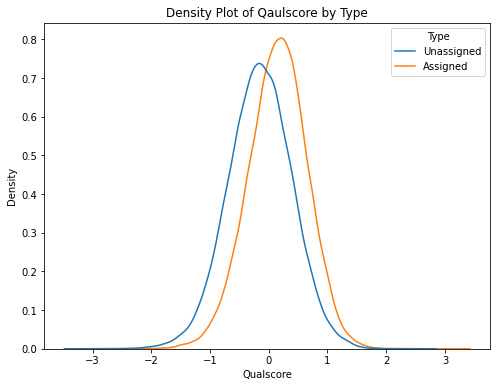

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def extract_scan(Spectrum):
    # 以点分隔，取倒数第3个
    parts = Spectrum.split('.')
    if len(parts) < 3:
        return None
    scan = parts[-3].lstrip('0')  # 去掉前导0
    return scan

# 应用到DataFrame，生成Type列
qualscore['scan'] = qualscore['Spectrum'].apply(extract_scan)
qualscore['Type'] = qualscore['scan'].apply(lambda x: 'Assigned' if x in filtered_scans else 'Unassigned')

# 绘制密度曲线
plt.figure(figsize=(8, 6))
sns.kdeplot(data=qualscore, x='Qualscore', hue='Type', common_norm=False)
plt.title('Density Plot of Qaulscore by Type')
plt.xlabel('Qualscore')
plt.ylabel('Density')
plt.show()

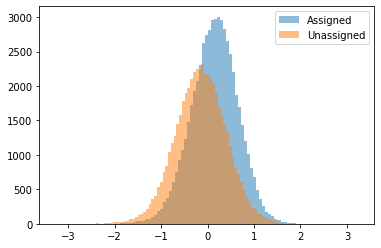

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# 分别画每一类
for t in ['Assigned', 'Unassigned']:
    subset = qualscore[qualscore['Type'] == t]
    plt.hist(subset['Qualscore'], bins=100, alpha=0.5, label=t)
plt.legend()
plt.show()

In [45]:
qualscore.head()
qualscore.to_csv('qualscore_0703.csv', index=False)

In [55]:
qualscore.head()

,Spectrum,Probability,Qualscore,scan,Type
0,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...,0.0,-0.074127,76,Unassigned
1,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...,0.0,-0.224617,79,Unassigned
2,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...,0.0,-0.487477,81,Unassigned
3,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...,0.0,0.095747,82,Unassigned
4,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...,0.0,0.046192,83,Unassigned


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 假设你的DataFrame名为qualscore
# bins和labels可根据你的数据分布调整
bins = [-np.inf, -1, -0.5, 0, 0.5, 1, 1.5, np.inf]
labels = ['≤-1', '-1,-0.5', '-0.5,0', '0,0.5', '0.5,1', '1,1.5', '≥1.5']

qualscore['score_bin'] = pd.cut(qualscore['Qualscore'], bins=bins, labels=labels, right=True, include_lowest=True)

# 统计每个区间内不同Type的数量
grouped = qualscore.groupby(['score_bin', 'Type']).size().unstack(fill_value=0)

/tmp/ipykernel_12075/3064286699.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = qualscore.groupby(['score_bin', 'Type']).size().unstack(fill_value=0)


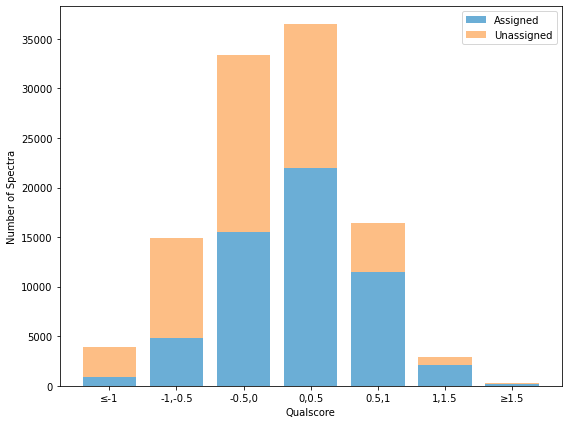

In [57]:
fig, ax = plt.subplots(figsize=(8, 6))
bottom = np.zeros(len(grouped))
colors = ['#6baed6', '#fdbe85']  # 可根据Type数量和需求调整

for i, type_val in enumerate(grouped.columns):
    vals = grouped[type_val]
    ax.bar(grouped.index, vals, bottom=bottom, label=type_val, color=colors[i % len(colors)])
    bottom += vals

ax.set_ylabel('Number of Spectra')
ax.set_xlabel('Qualscore')
ax.legend()
plt.tight_layout()
plt.show()

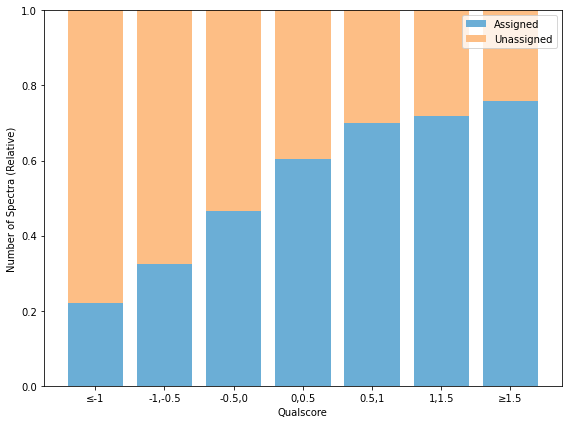

In [59]:
grouped_rel = grouped.div(grouped.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 6))
bottom = np.zeros(len(grouped_rel))

for i, type_val in enumerate(grouped_rel.columns):
    vals = grouped_rel[type_val]
    ax.bar(grouped_rel.index, vals, bottom=bottom, label=type_val, color=colors[i % len(colors)])
    bottom += vals

ax.set_ylabel('Number of Spectra (Relative)')
ax.set_xlabel('Qualscore')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

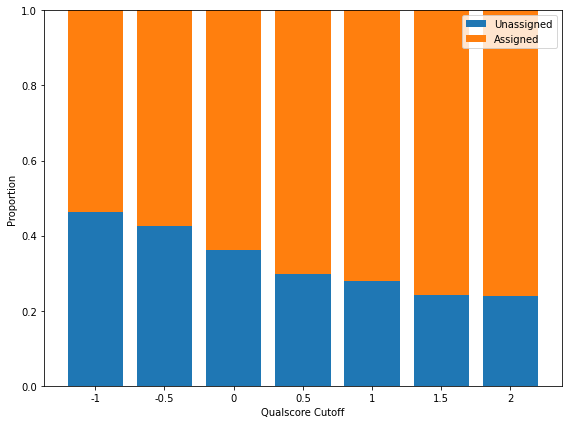

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cutoffs = [-1, -0.5, 0, 0.5, 1, 1.5, 2]
type_names = qualscore['Type'].unique()

# 统计每个cutoff下各Type的数量
proportion_data = []
for c in cutoffs:
    filtered = qualscore[qualscore['Qualscore'] > c]
    total = len(filtered)
    row = []
    for t in type_names:
        count = (filtered['Type'] == t).sum()
        prop = count / total if total > 0 else 0
        row.append(prop)
    proportion_data.append(row)

proportion_data = np.array(proportion_data)  # shape: (len(cutoffs), len(type_names))

# 堆叠柱状图
fig, ax = plt.subplots(figsize=(8, 6))
bottom = np.zeros(len(cutoffs))
for i, t in enumerate(type_names):
    ax.bar([str(c) for c in cutoffs], proportion_data[:, i], bottom=bottom, label=t)
    bottom += proportion_data[:, i]

ax.set_xlabel('Qualscore Cutoff')
ax.set_ylabel('Proportion')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

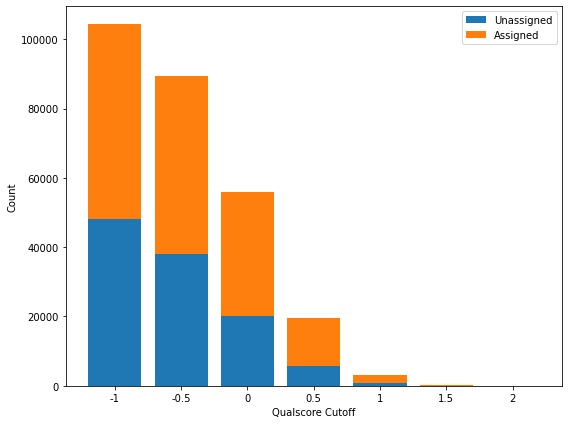

In [64]:
# 统计每个cutoff下各Type的绝对数量
count_data = []
for c in cutoffs:
    filtered = qualscore[qualscore['Qualscore'] > c]
    row = []
    for t in type_names:
        count = (filtered['Type'] == t).sum()
        row.append(count)
    count_data.append(row)

count_data = np.array(count_data)  # shape: (len(cutoffs), len(type_names))

# 堆叠柱状图
fig, ax = plt.subplots(figsize=(8, 6))
bottom = np.zeros(len(cutoffs))
for i, t in enumerate(type_names):
    ax.bar([str(c) for c in cutoffs], count_data[:, i], bottom=bottom, label=t)
    bottom += count_data[:, i]

ax.set_xlabel('Qualscore Cutoff')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

# 输入2

In [46]:
import xml.etree.ElementTree as ET
xml="./unfiltered_modified_2.pep.xml"
# 2. 处理2.pep.xml
tree = ET.parse(xml)
root = tree.getroot()

# 自动提取命名空间
namespace = ""
for elem in root.iter():
    if elem.tag.endswith("spectrum_query"):
        namespace = elem.tag.split("}")[0] + "}"
        break
# 假设qualscore['scan']是int类型
all_results = []
scan_prob = {}

for spectrum_query in root.iter(f"{namespace}spectrum_query"):
    scan = int(spectrum_query.attrib['start_scan'])
    for peptideprophet_result in spectrum_query.iter(f"{namespace}peptideprophet_result"):
        prob = float(peptideprophet_result.attrib.get("probability", 0))
        scan_prob[scan] = prob
        all_results.append((scan, prob))
        
def get_type(scan):
    scan=int(scan)
    prob = scan_prob.get(scan, None)
    if prob == 1 :
        return 'Assigned'
    elif prob == 0:
        return 'Unassigned'
    else:
        return 'Unknown'

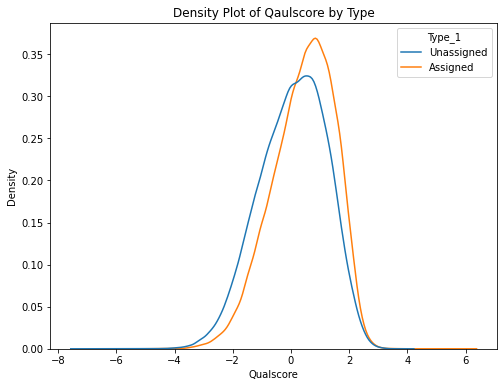

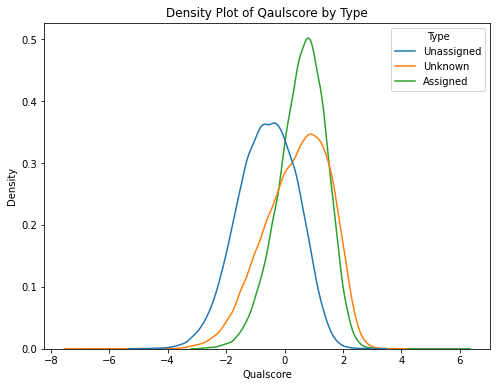

In [47]:
import pandas as pd
qualscore = pd.read_table(
    "./test_20250704",
    header=None,
    sep='\t',
    names=['Spectrum', 'Probability', 'Qualscore']
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def extract_scan(Spectrum):
    # 以点分隔，取倒数第3个
    parts = Spectrum.split('.')
    if len(parts) < 3:
        return None
    scan = parts[-3].lstrip('0')  # 去掉前导0
    return scan

# 应用到DataFrame，生成Type列
qualscore['scan'] = qualscore['Spectrum'].apply(extract_scan)
qualscore['Type_1'] = qualscore['scan'].apply(lambda x: 'Assigned' if x in filtered_scans else 'Unassigned')
qualscore['Type'] = qualscore['scan'].apply(get_type)
# 绘制密度曲线
plt.figure(figsize=(8, 6))
sns.kdeplot(data=qualscore, x='Qualscore', hue='Type_1', common_norm=False)
plt.title('Density Plot of Qaulscore by Type')
plt.xlabel('Qualscore')
plt.ylabel('Density')
plt.show()
# 绘制密度曲线
plt.figure(figsize=(8, 6))
sns.kdeplot(data=qualscore, x='Qualscore', hue='Type', common_norm=False)
plt.title('Density Plot of Qaulscore by Type')
plt.xlabel('Qualscore')
plt.ylabel('Density')
plt.show()

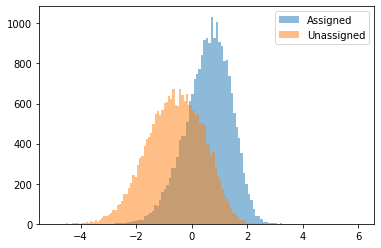

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# 分别画每一类
for t in ['Assigned', 'Unassigned']:
    subset = qualscore[qualscore['Type'] == t]
    plt.hist(subset['Qualscore'], bins=100, alpha=0.5, label=t)
plt.legend()
plt.show()

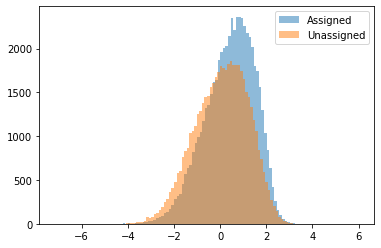

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# 分别画每一类
for t in ['Assigned', 'Unassigned']:
    subset = qualscore[qualscore['Type_1'] == t]
    plt.hist(subset['Qualscore'], bins=100, alpha=0.5, label=t)
plt.legend()
plt.show()

In [50]:
# 查看有多少qualscore大于1，但是unassigned的谱图
result = qualscore[(qualscore['Type'] == 'Unassigned') & (qualscore['Qualscore'] > 1)]
print(result)

                                                 Spectrum  Probability  \
0       CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...          0.0   
3       CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...          0.0   
4       CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...          0.0   
35      CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...          0.0   
100     CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...          0.0   
...                                                   ...          ...   
107599  CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...          0.0   
107684  CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...          0.0   
107705  CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...          0.0   
107787  CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...          0.0   
108040  CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...          0.0   

        Qualscore    scan      Type_1        Type  
0        1.486393      76  Unassigned  Unassigned  
3      

# 特征权重

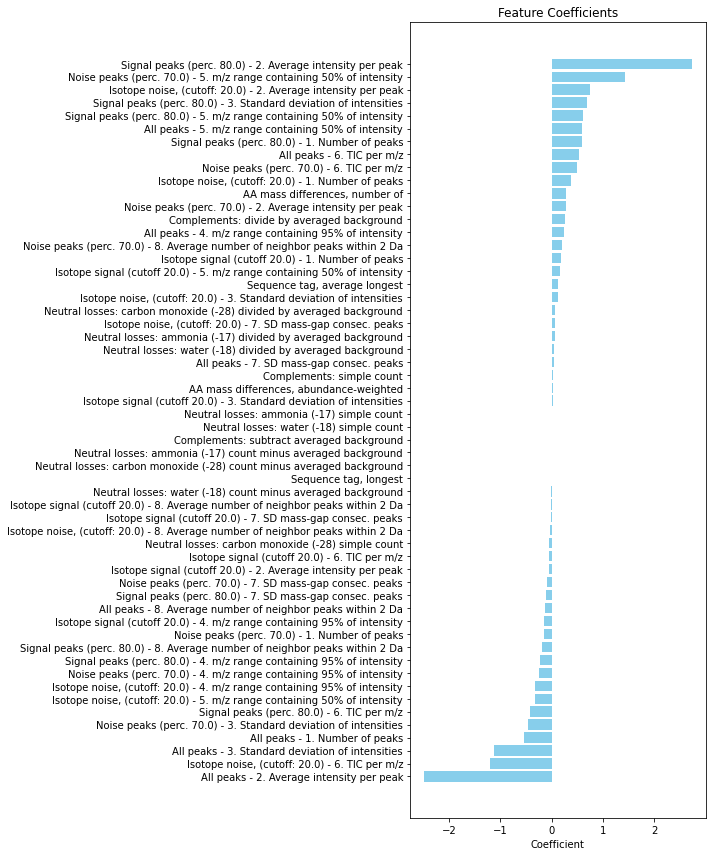

In [25]:
import pandas as pd

data = []
with open('test_20250703.coef', 'r') as f:
    lines = f.readlines()[2:]  # 跳过前两行
    for line in lines:
        line = line.strip()
        if ':' in line:
            idx = line.rfind(':')  # 找到最后一个冒号的位置
            name = line[:idx].strip()
            try:
                value = float(line[idx+1:].strip())
                data.append((name, value))
            except ValueError:
                continue  # 跳过无法转成float的行

df = pd.DataFrame(data, columns=['Feature', 'Coefficient'])
# print(df)
plt.figure(figsize=(10, 12))
df_sorted = df.sort_values('Coefficient')
plt.barh(df_sorted['Feature'], df_sorted['Coefficient'], color='skyblue')
plt.xlabel('Coefficient')
plt.title('Feature Coefficients')
plt.tight_layout()
plt.show()

图片已保存为 feature_coefficients.pdf


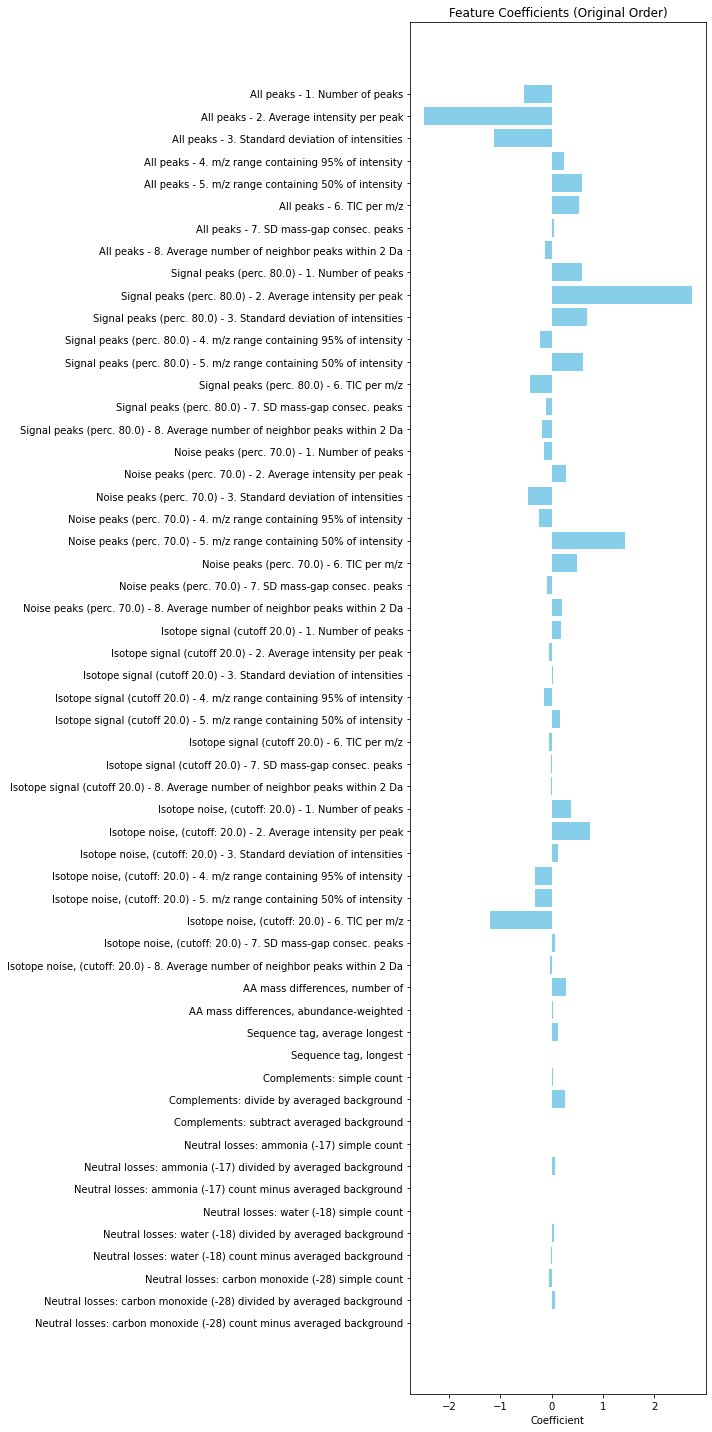

In [26]:
plt.figure(figsize=(10, 20))
plt.barh(df['Feature'][::-1], df['Coefficient'][::-1], color='skyblue')
plt.xlabel('Coefficient')
plt.title('Feature Coefficients (Original Order)')
plt.tight_layout()
plt.savefig('feature_coefficients.pdf', dpi=300)
print("图片已保存为 feature_coefficients.pdf")
plt.show()

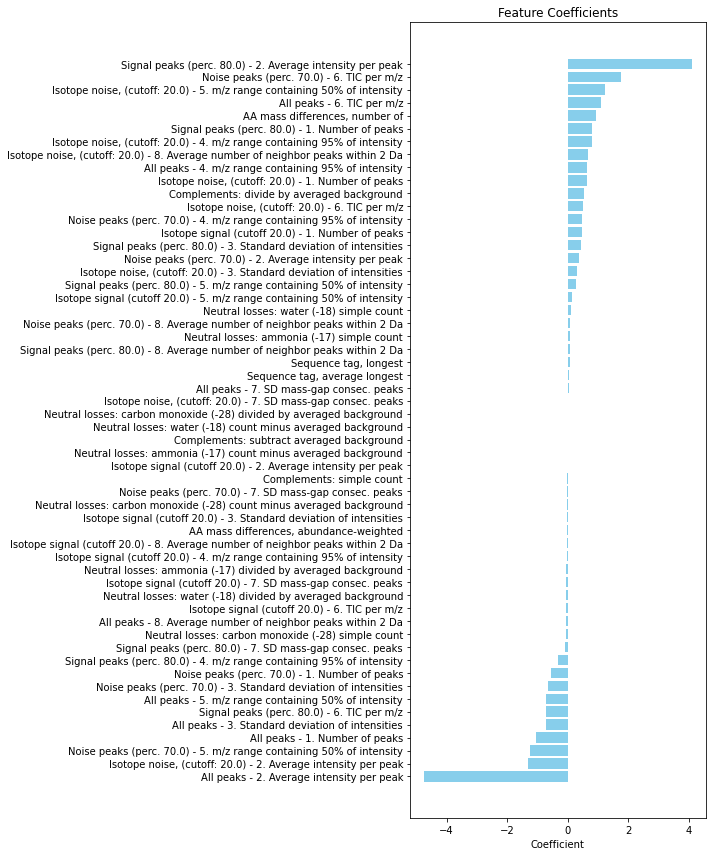

In [28]:
import pandas as pd

data = []
with open('test_20250704.coef', 'r') as f:
    lines = f.readlines()[2:]  # 跳过前两行
    for line in lines:
        line = line.strip()
        if ':' in line:
            idx = line.rfind(':')  # 找到最后一个冒号的位置
            name = line[:idx].strip()
            try:
                value = float(line[idx+1:].strip())
                data.append((name, value))
            except ValueError:
                continue  # 跳过无法转成float的行

df = pd.DataFrame(data, columns=['Feature', 'Coefficient'])

plt.figure(figsize=(10, 12))
df_sorted = df.sort_values('Coefficient')
plt.barh(df_sorted['Feature'], df_sorted['Coefficient'], color='skyblue')
plt.xlabel('Coefficient')
plt.title('Feature Coefficients')
plt.tight_layout()
plt.show()